In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *

In [3]:
evaluations_dt = pd.read_csv('../models_performances_21042025.csv')
evaluations_dt = evaluations_dt.sort_values(by=['spearman','mse'], ascending = [False, True]).reset_index(drop=True)

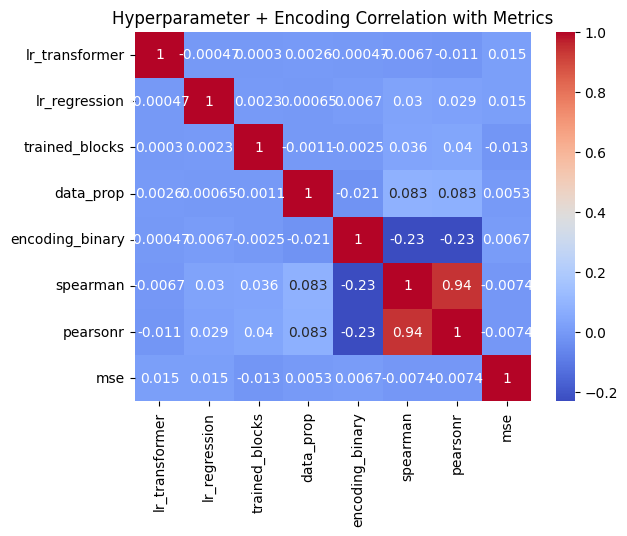

Encoding vs Spearman correlation: nan (p = nan)


/tmp/ipykernel_2849119/3789611503.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')]['lr_transformer'] = evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')]['lr_transformer'].astype(float)


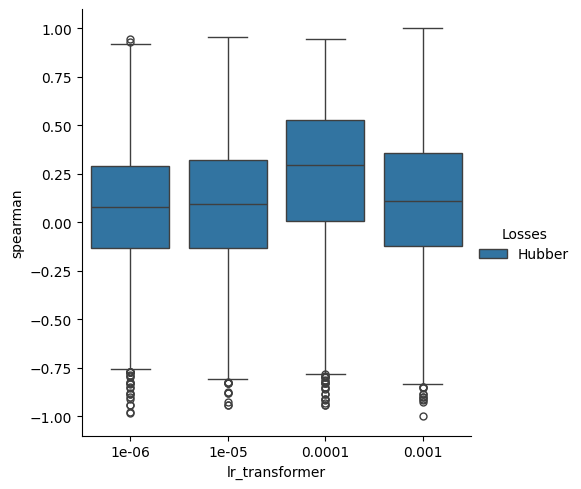

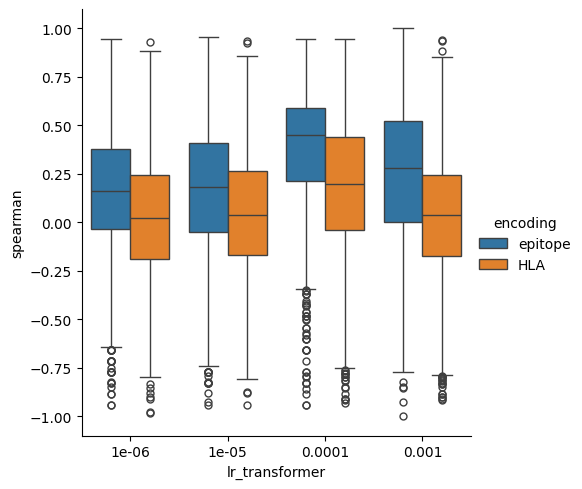

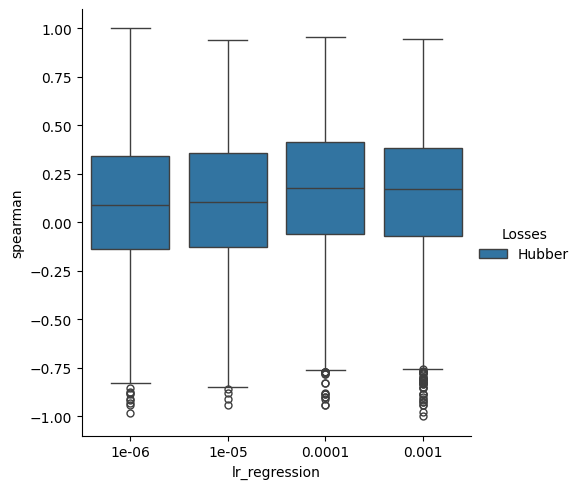

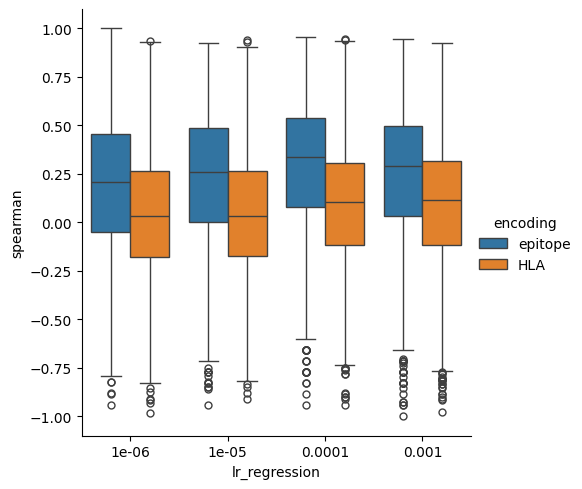

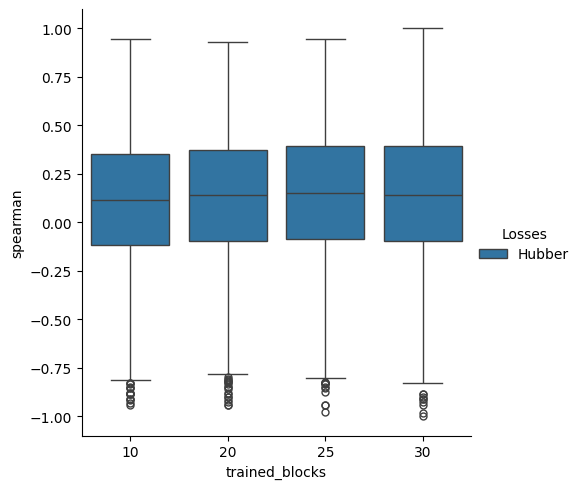

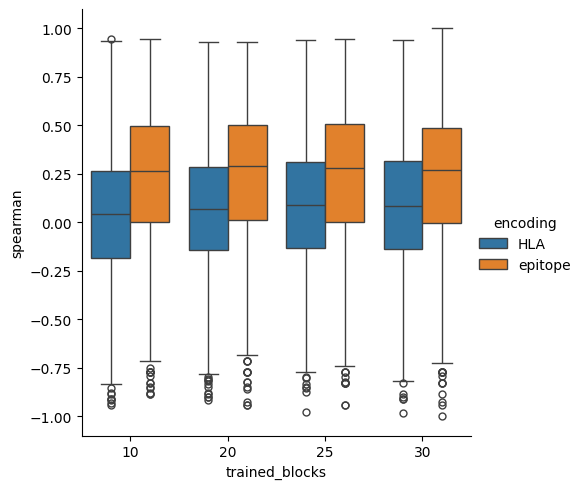

In [60]:
# Copy the DataFrame
df_corr = evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')][evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')]['time'].str.contains('2025-04-1')].copy()

# Convert 'encoding' to binary (e.g., epitope=0, HLA=1)
df_corr['Losses_binary'] = df_corr['Losses'].map({'MSE': 0, 'Hubber': 1})

# Convert 'encoding' to binary (e.g., epitope=0, HLA=1)
df_corr['encoding_binary'] = df_corr['encoding'].map({'epitope': 0, 'HLA': 1})

# Select numeric columns
numeric_hyperparams = df_corr[[
    'lr_transformer', 'lr_regression', 'trained_blocks', 'data_prop', 'encoding_binary',  'spearman', 'pearsonr', 'mse'
]].astype(float)

# Compute correlation matrix
correlation_matrix = numeric_hyperparams.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Hyperparameter + Encoding Correlation with Metrics")
plt.show()


from scipy.stats import pointbiserialr
# Point-biserial correlation
r, p = pointbiserialr(df_corr['encoding_binary'], df_corr['spearman'])
print(f"Encoding vs Spearman correlation: {r:.3f} (p = {p:.3g})")

evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')]['lr_transformer'] = evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')]['lr_transformer'].astype(float)

sns.catplot(data=evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')], x='lr_transformer', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')], x='lr_transformer', y='spearman', hue='encoding', kind='box')

sns.catplot(data=evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')], x='lr_regression', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')], x='lr_regression', y='spearman', hue='encoding', kind='box')


sns.catplot(data=evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')], x='trained_blocks', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt[evaluations_dt['time'].str.contains('2025-04-1')], x='trained_blocks', y='spearman', hue='encoding', kind='box')

In [56]:
evaluations_dt[(evaluations_dt['HLA'].str.contains('B5701'))  & (evaluations_dt['time'].str.contains('2025-04-1'))]['encoding'].unique()

array(['epitope'], dtype=object)

In [47]:
evaluations_dt_sorted =  evaluations_dt[(evaluations_dt['time'].str.contains('2025-04-1'))].sort_values(by='mse', ascending = True)
evaluations_dt_sorted['HLA'] = evaluations_dt_sorted['HLA'].str.replace('HLA','')
evaluations_dt_sorted[evaluations_dt_sorted['HLA'] == 'A1101']

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model
672,A1101,Hubber,HLA,0.50,30,0.000100,0.000100,110,0.797718,0.783970,0.736651,0.654020,0.611662,0.858284,2025-04-18 06:36:05,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
764,A1101,Hubber,HLA,0.95,30,0.000100,0.000100,110,0.790362,0.776472,0.799711,0.725858,0.578419,0.894265,2025-04-18 16:23:43,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
602,A1101,Hubber,HLA,0.80,25,0.001000,0.000001,110,0.804948,0.769275,0.804534,0.688395,0.575876,0.896958,2025-04-19 02:45:46,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
1046,A1101,Hubber,HLA,0.95,30,0.000100,0.000001,110,0.772395,0.760132,0.814449,0.701320,0.570649,0.902468,2025-04-19 18:50:25,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
1022,A1101,Hubber,HLA,0.50,30,0.000100,0.000001,110,0.774255,0.747570,0.851851,0.748438,0.550932,0.922958,2025-04-18 10:49:41,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,A1101,Hubber,HLA,0.20,30,0.000010,0.001000,110,0.451933,0.297176,4.151240,1.722255,-1.188396,2.037459,2025-04-18 15:04:49,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
40784,A1101,Hubber,HLA,0.20,20,0.000001,0.001000,110,-0.262445,-0.338417,4.917203,1.744238,-1.592187,2.217477,2025-04-18 23:20:13,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
15958,A1101,Hubber,HLA,0.20,10,0.001000,0.001000,110,0.355219,0.385688,5.382459,1.995826,-1.837454,2.320013,2025-04-19 08:31:09,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
13575,A1101,Hubber,HLA,0.95,10,0.000001,0.001000,110,0.403214,0.370863,6.255065,2.098985,-2.297463,2.501013,2025-04-19 06:04:34,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA


In [42]:
evaluations_dt_sorted =  evaluations_dt[(evaluations_dt['time'].str.contains('2025-04-1'))].sort_values(by='mse', ascending = True)
evaluations_dt_sorted['HLA'] = evaluations_dt_sorted['HLA'].str.replace('HLA','')
evaluations_dt_sorted['Model'] = evaluations_dt_sorted['HLA'] + ' ' + evaluations_dt_sorted['encoding']
evaluations_dt_sorted = evaluations_dt_sorted.drop_duplicates('Model')
# evaluations_dt_sorted #.sort_values(by='spearman', ascending = False)

results = []
test_datasets_list = []

# Get unique HLA alleles
alleles = evaluations_dt_sorted['HLA'].unique()

for allele in alleles:
    # Load training data for the current allele
    formatted_HLA = allele.replace('*', '').replace(':', '')  # e.g., HLAB0801
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"
    epitope_data = pd.read_csv(train_fasta, header=None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    
    # Clean and filter the training data
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
    epitope_data = epitope_data[epitope_data["Year_submission"] < 2019]

    # Load test data for the current allele
    test_path = evaluations_dt_sorted[evaluations_dt_sorted['HLA'] == allele]['path'].values[0]
    test_dataset = pd.read_csv(test_path)
    
    # Remove training sequences from the test data
    test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
    
    # If the filtered test dataset is empty, skip this allele
    if test_dataset.empty:
        continue

    # Store the test dataset with an added column for HLA
    test_dataset = test_dataset.copy()  # Ensure we're not modifying the original DataFrame unexpectedly
    test_dataset['HLA'] = allele
    test_datasets_list.append(test_dataset)
    
    # Only compute metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        
        results.append({
            "HLA": allele,
            "spearman": spearman_str,
            "pearsonr": pearson_str,
            "mse": mse_str,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data),
        })
else:
    print(f"All test datasets were empty for HLA {allele}. Skipping this allele.")

# Create a DataFrame with the metrics results
metrics_df = pd.DataFrame(results)

# Concatenate all test datasets into a single DataFrame
if test_datasets_list:
    test_datasets_df = pd.concat(test_datasets_list, ignore_index=True)
else:
    test_datasets_df = pd.DataFrame()  # empty DataFrame if no test datasets were stored

# Now you have:
# - metrics_df: contains the computed metrics for each HLA allele.
# - test_datasets_df: contains all the filtered test datasets with an HLA identifier.

All test datasets were empty for HLA A2402. Skipping this allele.


In [43]:
pd.merge(left=metrics_df, right=evaluations_dt_sorted[['HLA','time']], on='HLA', how='left').sort_values(by='time').reset_index(drop=True)

,HLA,spearman,pearsonr,mse,test_size,path,training_data,time
0,B0801,0.49,0.61,0.75,53,/global/scratch/users/sergiomar10/losses/ESMCB...,2374,2025-04-17 19:09:36
1,A0301,0.58,0.56,1.5,223,/global/scratch/users/sergiomar10/losses/ESMCB...,6278,2025-04-17 19:29:03
2,B0702,0.58,0.67,1.3,109,/global/scratch/users/sergiomar10/losses/ESMCB...,3724,2025-04-18 05:03:38
3,B3801,0.31,0.44,1.6,12,/global/scratch/users/sergiomar10/losses/ESMCB...,149,2025-04-18 05:46:51
4,B1501,0.75,0.8,0.71,22,/global/scratch/users/sergiomar10/losses/ESMCB...,3788,2025-04-18 05:59:28
5,A1101,0.8,0.78,0.74,110,/global/scratch/users/sergiomar10/losses/ESMCB...,5717,2025-04-18 06:36:05
6,C1502,-0.1,0.14,0.26,9,/global/scratch/users/sergiomar10/losses/ESMCB...,181,2025-04-18 06:42:33
7,B5101,0.36,0.66,0.43,7,/global/scratch/users/sergiomar10/losses/ESMCB...,2243,2025-04-18 06:55:42
8,A0216,-0.24,-0.28,0.47,8,/global/scratch/users/sergiomar10/losses/ESMCB...,604,2025-04-18 10:32:25
9,A8001,0.82,0.8,0.56,30,/global/scratch/users/sergiomar10/losses/ESMCB...,1123,2025-04-18 10:44:39


In [25]:
hla_sequences = []

# Process each HLA and its evaluation file
for hla, eval_path in evaluations_dt_sorted[['HLA', 'path']].values:

    # # Load evaluation data
    dt = pd.read_csv(eval_path)
    sequences = dt['sequence'].unique()
    hla_formatted = f"HLA-{hla}"  # e.g., 'HLA-A1101'

    # Collect HLA and sequence pairs
    for seq in sequences:
        hla_sequences.append([hla_formatted, seq])


In [8]:
# Load Data S2: Monoallelic benchmark dataset with predictions
test_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S2.csv')

In [9]:
test_data['hla'] = test_data['hla'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

In [10]:
evaluations_dt_sorted = evaluations_dt[evaluations_dt['encoding'] == 'epitope'].sort_values(by='mse', ascending = True) #.drop_duplicates('HLA') #[evaluations_dt['Losses'] == 'MSE']
evaluations_dt_sorted = evaluations_dt_sorted[evaluations_dt_sorted['HLA'].apply(len) == 8] 
# evaluations_dt_sorted #.sort_values(by='spearman', ascending = False)

In [13]:
IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/IEDB_full_subset_filtered_out_MHCFlurry.csv', sep = ',', header = 0)
IEDB_full.head()

,Assay - Qualitative Measurement,peptide,MHC Restriction - Name
0,Positive-High,LITGRLQSL,HLA-A2
1,Positive,LIYDSSLCDL,HLA-A2
2,Positive,GLLGTLVQ,HLA-A2
3,Positive,NLTISDVSV,HLA-A2
4,Positive,LPAVVGLSPGEQEY,HLA-B*35:01


In [14]:
IEDB_full['HLA'] = IEDB_full['MHC Restriction - Name'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

In [29]:
import re
# # Set up SLURM script directory
sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/MHCF_ESMCBA'
os.makedirs(sh_file_dir, exist_ok=True)

evaluated_models_log = []  # Will hold dicts with info to save as CSV later


for hla in evaluations_dt_sorted['HLA'].unique():

    sorted_models = evaluations_dt_sorted[evaluations_dt_sorted['HLA'] == hla][['HLA', 'path']].values

    model_found = False

    for allele, eval_path in sorted_models:
        hla_clean = allele.replace('*', '').replace(':', '').replace(' ', '').replace('HLA', '').replace('-', '')
        model_dir = f'/global/scratch/users/sergiomar10/ESMCBA/models/weights'

        model_filename = os.path.basename(eval_path).replace('evaluation_', '').replace('.csv', '_final.pth')
        model_path = os.path.join(model_dir, model_filename)

        if not os.path.exists(model_path):
            print(f"❌ Model not found: {model_path}")
            continue  # try next one
        else:
            print(f"✅ Model found for {allele}: {model_path}")
            model_found = True
            break  # stop checking once you find a good model

    if not model_found:
        print(f"⚠️ Skipping HLA {hla} — no valid model found.")
        continue  # skip this HLA

    # Get peptides for this allele
    peptides = IEDB_full[IEDB_full['HLA'] == hla]['peptide'].unique()

        # Filter peptides
    peptides = [
        pep for pep in peptides
        if 8 <= len(pep) <= 11 and not re.search(r'[<\(\)\*\s\+]', pep)
    ]

    if len(peptides) == 0:
        print(f"⚠️ No peptides found for {allele}. Skipping.")
        continue

    # Prepare job script
    run_id = f"MS_QUALPEPTIDDES_MHCFLURRY_{hla_clean}"
    peptide_str = ' '.join(peptides)

    esmcba_cmd = (
        f"python3 /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/model_evaluation.py "
        f"--model_path {model_path} "
        f"--hla {allele} "
        f"--output_dir /global/scratch/users/sergiomar10/benchmark/MSE_loss/qualitative_predictions "
        f"--peptides {peptide_str}"
    )


    sh_filepath = os.path.join(sh_file_dir, f"{run_id}.sh")
    try:
        with open(sh_filepath, 'w') as sh_file:
            sh_file.write('#!/bin/bash\n')
            sh_file.write('#SBATCH --account=co_nilah\n')
            sh_file.write('#SBATCH --partition=savio3_gpu\n')
            sh_file.write('#SBATCH --qos=savio_lowprio\n')
            sh_file.write('#SBATCH --cpus-per-task=4\n')
            sh_file.write('#SBATCH --gres=gpu:1\n')
            sh_file.write('#SBATCH --time=00:40:00\n')
            sh_file.write(f'#SBATCH --job-name={run_id}\n')
            sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.out\n')
            sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.err\n')
            sh_file.write('\n')
            sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
            sh_file.write('conda activate /clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian\n')
            sh_file.write('\n')
            sh_file.write(f"{esmcba_cmd}\n")

        os.chmod(sh_filepath, 0o755)
        print(f"✅ Created SLURM script: {sh_filepath}")

        evaluated_models_log.append({
    'HLA': allele,
    'model_path': model_path,
    'eval_path': eval_path,
    'script_path': sh_filepath,
    'num_peptides': len(peptides)
})

    except Exception as e:
        print(f"❌ Error creating script for {run_id}: {e}")


✅ Model found for HLAA0206: /global/scratch/users/sergiomar10/ESMCBA/models/weights/ESMCBA_epitope_0.5_20_ESMMASK_epitope_FT_25_0.0001_1e-06_AUG_1_HLAA0206_2_0.001_1e-06__1_A0206_Hubber_A0206_final.pth
✅ Created SLURM script: /global/scratch/users/sergiomar10/slurm_jobs/MHCF_ESMCBA/MS_QUALPEPTIDDES_MHCFLURRY_A0206.sh
❌ Model not found: /global/scratch/users/sergiomar10/ESMCBA/models/weights/ESMCBA_epitope_0.8_20_ESMMASK_epitope_FT_25_0.001_5e-05_AUG_6_HLAB4506_1_0.0001_1e-05__1_B4506_0404_Hubber_B4506_final.pth
❌ Model not found: /global/scratch/users/sergiomar10/ESMCBA/models/weights/ESMCBA_epitope_0.5_20_ESMMASK_epitope_FT_25_0.001_5e-05_AUG_6_HLAB4506_1_1e-05_1e-05__2_B4506_0404_Hubber_B4506_final.pth
❌ Model not found: /global/scratch/users/sergiomar10/ESMCBA/models/weights/ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_25_0.001_5e-05_AUG_6_HLAB4506_1_0.0001_1e-05__1_B4506_0404_Hubber_B4506_final.pth
❌ Model not found: /global/scratch/users/sergiomar10/ESMCBA/models/weights/ESMCBA_epito

In [26]:
model_path

'/global/scratch/users/sergiomar10/ESCMBA/models/weights/ESMCBA_epitope_0.8_30_ESMMASK_epitope_FT_25_0.0001_1e-06_AUG_3_HLAA2402_2_0.001_0.001__2_A2402_Hubber_A2402_final.pth'

In [ ]:
eval_model_df = pd.DataFrame(evaluated_models_log)

In [ ]:
eval_model_df['model_path'] = eval_model_df['model_path'].str.replace('/global/scratch/users/sergiomar10/models/','')

In [ ]:
import shutil

destination_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA'
os.makedirs(destination_dir, exist_ok=True)

for row in evaluated_models_log:
    src = row['model_path']
    filename = os.path.basename(src)
    dest = os.path.join(destination_dir, filename)

    try:
        shutil.copy2(src, dest)  # copy2 preserves metadata
        print(f"✅ Copied {filename} to {destination_dir}")
    except Exception as e:
        print(f"❌ Failed to copy {src} → {dest}: {e}")


✅ Copied ESMCBA_epitope_0.5_20_ESMMASK_epitope_FT_25_0.0001_1e-06_AUG_1_HLAA0206_2_0.001_1e-06__1_A0206_Hubber_A0206_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_25_0.001_0.001_AUG_6_HLAA0203_2_0.001_0.001__2_A0203_Hubber_A0203_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.5_20_ESMMASK_epitope_FT_25_0.001_1e-06_AUG_3_HLAB3701_1_0.0001_1e-05__1_B3701_0404_Hubber_B3701_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_20_ESMMASK_epitope_FT_20_0.001_1e-06_AUG_1_HLAA2501_1_0.0001_1e-06__1_A2501_0404_Hubber_A2501_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_20_0.001_0.001_AUG_1_HLAA3301_5_0.001_1e-06__4_A3301_Hubber_A3301_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_25_0.001_1e-05_AUG_6_HLAA6802_2_0.001_1e-06__4_A

In [ ]:
# Load Data S3: Training data for MHCflurry 2.0 BA predictor
training_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S3.csv')
print(f"Training data shape: {training_data.shape}")

Training data shape: (713069, 12)


In [ ]:
training_data['allele'] = training_data['allele'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

In [ ]:
testing_set_filtered = pd.DataFrame()

for HLA in test_datasets_df['HLA'].unique():
    training_data_subset = training_data[training_data['allele'] == HLA]

    test_datasets_df_subset = test_datasets_df[test_datasets_df['HLA'] == HLA]
    test_datasets_df_subset = test_datasets_df_subset[~test_datasets_df_subset['sequence'].isin(training_data_subset['peptide'])]

    testing_set_filtered = pd.concat([testing_set_filtered, test_datasets_df_subset], ignore_index=True)

In [1]:
import os
import pandas as pd

# Load your test data
# testing_set_filtered = pd.read_csv("path/to/testing_set_filtered.csv")

# Output dirs
sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/MHCF_ESMCBA'
output_dir = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/NETMHCSPAN4'
mhcflurry_out_dir = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/MHCFlurry'
os.makedirs(sh_file_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
os.makedirs(mhcflurry_out_dir, exist_ok=True)

aa = set("ACDEFGHIKLMNPQRSTVWY")  # valid amino acids

# Loop through each HLA in testing set
unique_hlas = testing_set_filtered['HLA'].unique()
print(f"📊 Found {len(unique_hlas)} unique HLAs in testing set.")

for allele in unique_hlas:
    allele_peptides = testing_set_filtered[testing_set_filtered['HLA'] == allele]['sequence'].unique()
    allele_clean = allele.replace('HLA-', '').replace('*', '').replace(':', '').replace(' ', '')

    # Clean peptides
    cleaned_peptides = [
        ''.join([aa_ for aa_ in p if aa_.upper() in aa])
        for p in allele_peptides if isinstance(p, str)
    ]
    cleaned_peptides = [p for p in cleaned_peptides if p]

    if len(cleaned_peptides) == 0:
        print(f"⚠️ No valid peptides found for {allele}. Skipping.")
        continue

    run_id = f"EVAL_MHCFLURRY_TEST_{allele_clean}"

    # Save to .pep FASTA file
    pepe = allele_clean.replace('HLA', 'HLA-')
    fasta_filename = os.path.join(output_dir, f"{pepe}.pep")
    with open(fasta_filename, "w") as fout:
        for i, pep in enumerate(cleaned_peptides, 1):
            fout.write(f">pep{i}\n{pep}\n")

    print(f"📁 Saved {len(cleaned_peptides)} peptides for {allele} to {fasta_filename}")

    # Build mhcflurry and netMHCpan commands
    mhcflurry_outfile = os.path.join(mhcflurry_out_dir, f"{allele_clean}_mhc_flurry.csv")
    mhcflurry_cmd = (
        f"mhcflurry-predict --alleles {allele_clean} "
        f"--peptides {' '.join(cleaned_peptides)} "
        f"--out {mhcflurry_outfile}"
    )

    netmhc_cmd = (
        f"cd {output_dir} && "
        f"/global/scratch/users/sergiomar10/ESMCBA/tools/netMHCpan-4.1/netMHCpan "
        f"-a {allele_clean} -f {allele_clean}.pep -BA -xls -xlsfile {allele_clean}_netmhc.xls"
    )

    # Write SLURM script
    sh_filepath = os.path.join(sh_file_dir, f"{run_id}.sh")
    try:
        with open(sh_filepath, 'w') as sh_file:
            sh_file.write('#!/bin/bash\n')
            sh_file.write('#SBATCH --account=co_nilah\n')
            sh_file.write('#SBATCH --partition=savio2_1080ti\n')
            sh_file.write('#SBATCH --qos=savio_lowprio\n')
            sh_file.write('#SBATCH --cpus-per-task=4\n')
            sh_file.write('#SBATCH --gres=gpu:1\n')
            sh_file.write('#SBATCH --time=00:40:00\n')
            sh_file.write(f'#SBATCH --job-name={run_id}\n')
            sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.out\n')
            sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.err\n\n')
            sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
            sh_file.write('conda activate /clusterfs/nilah/sergio/miniconda3/envs/cooltools\n\n')
            sh_file.write(f"{mhcflurry_cmd}\n")
            sh_file.write(f"{netmhc_cmd}\n")

        os.chmod(sh_filepath, 0o755)
        print(f"✅ Created SLURM script: {sh_filepath}")
    except Exception as e:
        print(f"❌ Error writing script for {allele}: {e}")


NameError: name 'testing_set_filtered' is not defined

In [ ]:
allele_clean.replace('HLA', 'HLA-')

'HLA-A2402'